# Notebook 16 — Integrated Equity 2-Step Early-Reversal Architecture

**Project:** SuperbCommand — Multi-Asset CTA Strategy  
**Purpose:** Integrate the Notebook 15 equity Early-Reversal pacing result into the full multi-asset research architecture and test whether the sleeve-level improvement survives portfolio aggregation.

This notebook makes one predeclared implementation change only:

- **Equities using SuperbCommand:** Early-Reversal entry becomes a **2-step 50% / 50% accumulation**.
- **Crypto using SuperbCommand:** Early-Reversal entry remains **immediate**.
- Other asset classes and all non-SuperbCommand components remain unchanged.
- No signal hyperparameters are optimised.
- No portfolio weighting method is re-optimised.
- The **2026 final holdout remains locked and is not accessed**.

Primary comparisons:

1. Existing portfolio walk-forward blend.
2. Dual Trend inverse-volatility benchmark.
3. Existing SuperbCommand-containing portfolio architecture.
4. New integrated architecture with equity 2-step pacing.

In [1]:
# ============================================================
# 16.1 — IMPORTS, DRIVE MOUNT, GLOBAL SETTINGS
# ============================================================

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception:
    pass

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy"
)

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results" / "notebook_16"
MANIFEST_DIR = PROJECT_ROOT / "manifests"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MANIFEST_DIR.mkdir(parents=True, exist_ok=True)

RESEARCH_END = pd.Timestamp("2025-12-31")
HOLDOUT_START = pd.Timestamp("2026-01-01")

WEEKS_PER_YEAR = 52.0

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Research data cutoff:", RESEARCH_END.date())
print("2026 holdout:", "LOCKED")

Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy
Research data cutoff: 2025-12-31
2026 holdout: LOCKED


## 16.2 Research design

Notebook 16 is intentionally an **integration test**, not another optimiser.

The equity pacing change was selected before this notebook:

- `ER_IMMEDIATE` → old SuperbCommand equity implementation.
- `ER_2_STEP` → new implementation, 50% of target exposure on the Early-Reversal start week and the remaining 50% one week later, subject to the signal still being active.

The key question is whether this small equity-sleeve refinement survives aggregation once the portfolio is reconstructed with the same weighting and blending machinery used in earlier notebooks.

In [2]:
# ============================================================
# 16.3 — ROBUST FILE DISCOVERY
# ============================================================

def find_first_existing(candidates):
    for p in candidates:
        p = Path(p)
        if p.exists():
            return p
    return None

def recursive_find(patterns):
    hits = []
    for pat in patterns:
        hits.extend(PROJECT_ROOT.rglob(pat))
    return sorted(set(hits))

# Signal panel from Notebook 02
SIGNAL_PATH = find_first_existing([
    DATA_PROCESSED / "superbcommand_weekly_signal_panel.parquet",
    DATA_PROCESSED / "superbcommand_signal_panel.parquet",
])

if SIGNAL_PATH is None:
    hits = recursive_find(["*signal*panel*.parquet", "*weekly*signal*.parquet"])
    SIGNAL_PATH = hits[0] if hits else None

# Portfolio / strategy return panels from prior notebooks
RETURN_CANDIDATES = recursive_find([
    "*return*panel*.parquet",
    "*strategy*returns*.parquet",
    "*portfolio*returns*.parquet",
    "*walkforward*.parquet",
    "*blend*.parquet",
])

print("Signal panel:", SIGNAL_PATH)
print("Candidate prior return files:")
for p in RETURN_CANDIDATES[:25]:
    print(" -", p)

if SIGNAL_PATH is None:
    raise FileNotFoundError("Could not locate the SuperbCommand weekly signal panel.")

Signal panel: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/superbcommand_weekly_signal_panel.parquet
Candidate prior return files:
 - /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/04_strategy_return_panel.parquet
 - /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/05_portfolio_return_panel.parquet
 - /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/06_baseline_return_panel.parquet
 - /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/07_walk_forward_return_panel.parquet
 - /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/08_composite_return_panel.parquet
 - /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/08_composite_walkforward_return.parquet
 - /content/drive/MyDrive/Colab No

In [4]:
# ============================================================
# 16.4 — LOAD AND NORMALISE SIGNAL PANEL
# ============================================================

sig = pd.read_parquet(SIGNAL_PATH).copy()

# ------------------------------------------------------------
# Recover ticker/date if stored in the index
# ------------------------------------------------------------
if "ticker" not in sig.columns:
    if isinstance(sig.index, pd.MultiIndex) and "ticker" in sig.index.names:
        sig = sig.reset_index()
    elif sig.index.name == "ticker":
        sig = sig.reset_index()

if "date" not in sig.columns:
    if isinstance(sig.index, pd.MultiIndex) and "date" in sig.index.names:
        sig = sig.reset_index()
    elif sig.index.name == "date":
        sig = sig.reset_index()

if "ticker" not in sig.columns or "date" not in sig.columns:
    raise KeyError(
        f"Signal panel must expose ticker/date after normalisation. "
        f"Columns={list(sig.columns)}; index={sig.index.names}"
    )

sig["date"] = pd.to_datetime(sig["date"])
sig = sig[sig["date"] <= RESEARCH_END].copy()

# ------------------------------------------------------------
# Derive asset class from the predeclared project universe
# Notebook 02 does not store asset_class directly.
# ------------------------------------------------------------
ASSET_CLASS_MAP = {
    # Equities
    "SPY": "equities",
    "EFA": "equities",
    "EEM": "equities",

    # Rates
    "SHY": "rates",
    "IEF": "rates",
    "TLT": "rates",
    "TIP": "rates",

    # Commodities
    "GLD": "commodities",
    "DBC": "commodities",

    # FX
    "UUP": "fx",

    # Crypto
    "BTC-USD": "crypto",
}

if "asset_class" not in sig.columns:
    sig["asset_class"] = sig["ticker"].map(ASSET_CLASS_MAP)

# Fail loudly if a ticker has not been classified.
unmapped = sorted(
    sig.loc[sig["asset_class"].isna(), "ticker"]
       .dropna()
       .astype(str)
       .unique()
       .tolist()
)

if unmapped:
    raise KeyError(
        "Notebook 16 encountered ticker(s) without a predeclared "
        f"asset-class mapping: {unmapped}"
    )

# ------------------------------------------------------------
# Validate fields actually required by Notebook 16
# ------------------------------------------------------------
required = [
    "ticker",
    "date",
    "close",
    "asset_class",
    "position_held",
    "early_reversal_active",
    "start_early_reversal",
]

missing = [c for c in required if c not in sig.columns]

if missing:
    raise KeyError(
        f"Missing required signal columns: {missing}. "
        f"Available columns: {list(sig.columns)}"
    )

sig = (
    sig.sort_values(["ticker", "date"])
       .reset_index(drop=True)
)

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------
print("Signal shape:", sig.shape)
print("Max signal date:", sig["date"].max().date())

print("\nTicker → asset-class mapping:")
display(
    sig[["ticker", "asset_class"]]
    .drop_duplicates()
    .sort_values(["asset_class", "ticker"])
    .reset_index(drop=True)
)

print("\nSignal-panel tail:")
display(sig[required].tail())

Signal shape: (11370, 58)
Max signal date: 2025-12-26

Ticker → asset-class mapping:


,ticker,asset_class
0,DBC,commodities
1,GLD,commodities
2,BTC-USD,crypto
3,EEM,equities
4,EFA,equities
5,SPY,equities
6,UUP,fx
7,IEF,rates
8,SHY,rates
9,TIP,rates



Signal-panel tail:


,ticker,date,close,asset_class,position_held,early_reversal_active,start_early_reversal
11365,UUP,2025-11-28,27.278376,fx,True,True,False
11366,UUP,2025-12-05,27.152668,fx,True,True,False
11367,UUP,2025-12-12,27.026962,fx,True,True,False
11368,UUP,2025-12-19,27.143000,fx,True,True,False
11369,UUP,2025-12-26,26.969999,fx,True,True,False


In [5]:
# ============================================================
# 16.5 — RECONSTRUCT WEEKLY UNDERLYING RETURNS
# ============================================================

sig["underlying_return"] = (
    sig.groupby("ticker", observed=True)["close"]
       .pct_change()
       .replace([np.inf, -np.inf], np.nan)
)

# One-week implementation lag remains enforced.
sig["underlying_return_fwd"] = (
    sig.groupby("ticker", observed=True)["underlying_return"].shift(-1)
)

print(sig[["ticker","date","close","underlying_return","underlying_return_fwd"]].tail())

      ticker       date      close  underlying_return  underlying_return_fwd
11365    UUP 2025-11-28  27.278376          -0.006340              -0.004608
11366    UUP 2025-12-05  27.152668          -0.004608              -0.004630
11367    UUP 2025-12-12  27.026962          -0.004630               0.004293
11368    UUP 2025-12-19  27.143000           0.004293              -0.006374
11369    UUP 2025-12-26  26.969999          -0.006374                    NaN


## 16.6 Construct old versus new SuperbCommand equity exposure

We reproduce the existing binary held/not-held exposure and then alter **only the Early-Reversal transition for equities**.

For the new equity rule:

- week 0 of a fresh Early-Reversal episode: `0.50 × target exposure`
- week 1: `1.00 × target exposure`
- subsequent held weeks: unchanged from the original SuperbCommand exposure
- if the Early-Reversal state terminates before week 1, the second tranche is not forced in

This preserves the original signal logic and changes only entry pacing.

In [6]:
# ============================================================
# 16.7 — BUILD ORIGINAL AND 2-STEP EQUITY EXPOSURES
# ============================================================

def build_equity_two_step_exposure(df):
    out = df.copy()
    out["sc_original_exposure"] = out["position_held"].astype(float)
    out["sc_integrated_exposure"] = out["sc_original_exposure"].copy()

    is_eq = out["asset_class"].astype(str).str.lower().eq("equities")

    # Episode identifier for Early-Reversal states.
    starts = out["start_early_reversal"].fillna(False).astype(bool)
    out["er_episode_id"] = (
        starts.groupby(out["ticker"]).cumsum()
    )

    out["er_week_in_episode"] = np.nan

    for ticker, g in out.groupby("ticker", sort=False):
        idx = g.index
        active = g["early_reversal_active"].fillna(False).astype(bool)
        start = g["start_early_reversal"].fillna(False).astype(bool)

        episode_counter = -1
        week_counter = None

        for i, is_active, is_start in zip(idx, active, start):
            if is_start:
                episode_counter += 1
                week_counter = 0
            elif is_active and week_counter is not None:
                week_counter += 1
            elif not is_active:
                week_counter = None

            if is_active and week_counter is not None:
                out.at[i, "er_week_in_episode"] = week_counter

    eq_er = is_eq & out["early_reversal_active"].fillna(False).astype(bool)

    # 50% on first ER week, then full exposure.
    first_week = eq_er & out["er_week_in_episode"].eq(0)
    out.loc[first_week, "sc_integrated_exposure"] = (
        0.5 * out.loc[first_week, "sc_original_exposure"]
    )

    # All later weeks retain original exposure.
    return out

sig2 = build_equity_two_step_exposure(sig)

diag = (
    sig2.loc[sig2["asset_class"].astype(str).str.lower().eq("equities"),
             ["ticker","date","early_reversal_active","start_early_reversal",
              "er_week_in_episode","sc_original_exposure","sc_integrated_exposure"]]
        .query("early_reversal_active == True")
        .head(30)
)
display(diag)

,ticker,date,early_reversal_active,start_early_reversal,er_week_in_episode,sc_original_exposure,sc_integrated_exposure
1749,EEM,2007-05-11,True,True,0.0,1.0,0.5
1750,EEM,2007-05-18,True,False,1.0,1.0,1.0
1751,EEM,2007-05-25,True,False,2.0,1.0,1.0
1752,EEM,2007-06-01,True,False,3.0,1.0,1.0
1753,EEM,2007-06-08,True,False,4.0,1.0,1.0
1754,EEM,2007-06-15,True,False,5.0,1.0,1.0
1755,EEM,2007-06-22,True,False,6.0,1.0,1.0
1756,EEM,2007-06-29,True,False,7.0,1.0,1.0
1757,EEM,2007-07-06,True,False,8.0,1.0,1.0
1758,EEM,2007-07-13,True,False,9.0,1.0,1.0


In [7]:
# ============================================================
# 16.8 — GENERATE OLD VS NEW SUPERBCOMMAND INSTRUMENT RETURNS
# ============================================================

# Exposure known at t is applied to return t+1.
sig2["ret_sc_original"] = (
    sig2["sc_original_exposure"] * sig2["underlying_return_fwd"]
)

sig2["ret_sc_integrated"] = (
    sig2["sc_integrated_exposure"] * sig2["underlying_return_fwd"]
)

# Only equities should differ.
non_eq = ~sig2["asset_class"].astype(str).str.lower().eq("equities")
max_non_eq_diff = (
    sig2.loc[non_eq, "ret_sc_integrated"] -
    sig2.loc[non_eq, "ret_sc_original"]
).abs().max()

print("Max non-equity return difference:", max_non_eq_diff)

Max non-equity return difference: 0.0


## 16.9 Import prior portfolio weights

The integration should use the portfolio-construction machinery already established in Notebook 05 and subsequent notebooks. This cell searches prior outputs for a dated instrument-weight panel.

Preferred method remains the established **hierarchical inverse-volatility** architecture unless a prior selected portfolio-weight file explicitly records another fixed method.

In [8]:
# ============================================================
# 16.10 — LOCATE PRIOR INSTRUMENT WEIGHT PANEL
# ============================================================

weight_hits = recursive_find([
    "*weight*panel*.parquet",
    "*portfolio*weights*.parquet",
    "*instrument*weights*.parquet",
])

print("Weight candidates:")
for p in weight_hits[:30]:
    print(" -", p)

def score_weight_file(path):
    try:
        x = pd.read_parquet(path)
        cols = [str(c).lower() for c in x.columns]
        score = 0
        score += 5 if "date" in cols else 0
        score += 5 if "ticker" in cols else 0
        score += 5 if "weight" in cols else 0
        score += 3 if any("inverse_vol" in c for c in cols) else 0
        score += 2 if isinstance(x.columns, pd.MultiIndex) else 0
        return score, x
    except Exception:
        return -1, None

scored = []
for p in weight_hits:
    sc, _ = score_weight_file(p)
    scored.append((sc, p))

scored = sorted(scored, reverse=True)
print("Top scored:")
for row in scored[:10]:
    print(row)

WEIGHT_PATH = scored[0][1] if scored and scored[0][0] > 0 else None

if WEIGHT_PATH is None:
    print("No usable prior instrument-weight panel found; Notebook 16 will reconstruct a simple hierarchical inverse-vol fallback.")
else:
    print("Selected weight file:", WEIGHT_PATH)

Weight candidates:
 - /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/05_portfolio_weights.parquet
 - /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/13B_substitution_reweighting_return_panel.parquet
Top scored:
(5, PosixPath('/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/05_portfolio_weights.parquet'))
(0, PosixPath('/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/13B_substitution_reweighting_return_panel.parquet'))
Selected weight file: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/05_portfolio_weights.parquet


In [9]:
# ============================================================
# 16.11 — NORMALISE / RECONSTRUCT HIERARCHICAL INVERSE-VOL WEIGHTS
# ============================================================

def make_hier_inverse_vol_fallback(sig_df, lookback=26, min_obs=13):
    x = sig_df[["date","ticker","asset_class","underlying_return"]].copy()
    x = x.sort_values(["ticker","date"])

    x["vol"] = (
        x.groupby("ticker", observed=True)["underlying_return"]
         .rolling(lookback, min_periods=min_obs)
         .std()
         .reset_index(level=0, drop=True)
    )

    x["inv_vol"] = 1.0 / x["vol"].replace(0, np.nan)

    # Equal risk budget by asset class, inverse vol within class.
    within = x.groupby(["date","asset_class"], observed=True)["inv_vol"].transform("sum")
    x["within_class_weight"] = x["inv_vol"] / within

    active_classes = (
        x.assign(valid=x["within_class_weight"].notna().astype(float))
         .groupby("date", observed=True)["asset_class"]
         .transform("nunique")
    )

    x["asset_class_weight"] = 1.0 / active_classes.replace(0, np.nan)
    x["weight"] = x["within_class_weight"] * x["asset_class_weight"]

    # Normalise exactly to one where possible.
    gross = x.groupby("date", observed=True)["weight"].transform("sum")
    x["weight"] = x["weight"] / gross

    return x[["date","ticker","asset_class","weight"]]

weights = None

if WEIGHT_PATH is not None:
    try:
        w = pd.read_parquet(WEIGHT_PATH).copy()

        # Long format
        if {"date","ticker","weight"}.issubset(w.columns):
            weights = w[["date","ticker","weight"]].copy()
            if "asset_class" in w.columns:
                weights["asset_class"] = w["asset_class"].values

        # Wide ticker matrix
        elif isinstance(w.index, pd.DatetimeIndex) and not isinstance(w.columns, pd.MultiIndex):
            temp = w.copy()
            temp.index.name = "date"
            weights = (
                temp.reset_index()
                    .melt(id_vars="date", var_name="ticker", value_name="weight")
            )

        # MultiIndex columns: try method/ticker structure.
        elif isinstance(w.columns, pd.MultiIndex):
            candidates = []
            for level in range(w.columns.nlevels):
                vals = pd.Index(w.columns.get_level_values(level)).astype(str)
                if vals.str.contains("inverse_vol", case=False).any():
                    candidates.append(level)

            if candidates:
                lvl = candidates[0]
                key = [c for c in w.columns.get_level_values(lvl).unique()
                       if "inverse_vol" in str(c).lower()][0]
                sub = w.xs(key, axis=1, level=lvl)
                sub.index.name = "date"
                weights = (
                    sub.reset_index()
                       .melt(id_vars="date", var_name="ticker", value_name="weight")
                )
    except Exception as e:
        print("Prior weight panel could not be normalised:", repr(e))

if weights is None:
    weights = make_hier_inverse_vol_fallback(sig2)

weights["date"] = pd.to_datetime(weights["date"])
weights = weights[weights["date"] <= RESEARCH_END].copy()

# Attach asset class if absent.
if "asset_class" not in weights.columns:
    class_map = sig2[["ticker","asset_class"]].drop_duplicates("ticker")
    weights = weights.merge(class_map, on="ticker", how="left")

print("Weight panel shape:", weights.shape)
display(weights.tail())

Weight panel shape: (12045, 4)


,date,ticker,weight,asset_class
12040,2025-11-28,UUP,0.316346,fx
12041,2025-12-05,UUP,0.306125,fx
12042,2025-12-12,UUP,0.292407,fx
12043,2025-12-19,UUP,0.281743,fx
12044,2025-12-26,UUP,0.279098,fx


In [10]:
# ============================================================
# 16.12 — BUILD PORTFOLIO-LEVEL ORIGINAL VS INTEGRATED SC RETURNS
# ============================================================

r = sig2[
    ["date","ticker","asset_class","ret_sc_original","ret_sc_integrated"]
].copy()

panel = weights.merge(r, on=["date","ticker"], how="inner", suffixes=("_w","_r"))

if "asset_class_r" in panel.columns:
    panel["asset_class"] = panel["asset_class_r"]
elif "asset_class_w" in panel.columns:
    panel["asset_class"] = panel["asset_class_w"]

panel["weighted_original"] = panel["weight"] * panel["ret_sc_original"]
panel["weighted_integrated"] = panel["weight"] * panel["ret_sc_integrated"]

portfolio_sc = (
    panel.groupby("date", observed=True)[["weighted_original","weighted_integrated"]]
         .sum(min_count=1)
         .rename(columns={
             "weighted_original":"SC_ORIGINAL_INV_VOL",
             "weighted_integrated":"SC_EQ_2STEP_INV_VOL",
         })
         .sort_index()
)

display(portfolio_sc.tail())

,SC_ORIGINAL_INV_VOL,SC_EQ_2STEP_INV_VOL
date,,
2025-11-28,-0.001930,-0.001930
2025-12-05,-0.001811,-0.001811
2025-12-12,0.002098,0.002098
2025-12-19,0.005027,0.005027
2025-12-26,NaN,NaN


## 16.13 Load established external portfolio benchmarks

Notebook 16 does not recreate or alter Dual Trend, TSMOM, passive, or the existing portfolio walk-forward blend. It imports the previously generated series wherever possible.

The benchmark of greatest interest is the prior **portfolio walk-forward blend**, because Notebook 12–13 established it as the strongest robust portfolio architecture before the equity pacing refinement.

In [11]:
# ============================================================
# 16.14 — DISCOVER PRIOR BENCHMARK RETURN SERIES
# ============================================================

benchmark_labels = {
    "PORTFOLIO_WF_BLEND",
    "DUAL_TREND_INV_VOL",
    "TSMOM_INV_VOL",
    "PASSIVE_INV_VOL",
}

def extract_named_series(path):
    try:
        x = pd.read_parquet(path)

        # Wide, simple columns.
        if isinstance(x.index, pd.DatetimeIndex):
            out = {}
            for c in x.columns:
                name = str(c)
                if name in benchmark_labels:
                    out[name] = x[c].rename(name)
            if out:
                return out

        # Long format.
        cols = set(map(str, x.columns))
        if {"date","strategy"}.issubset(cols):
            ret_col = next((c for c in ["return","weekly_return","strategy_return","ret"] if c in cols), None)
            if ret_col:
                out = {}
                for name in benchmark_labels:
                    z = x[x["strategy"].astype(str).eq(name)]
                    if not z.empty:
                        s = z.set_index(pd.to_datetime(z["date"]))[ret_col].rename(name)
                        out[name] = s
                if out:
                    return out

        # MultiIndex columns
        if isinstance(x.columns, pd.MultiIndex):
            out = {}
            for c in x.columns:
                joined = "__".join(map(str,c))
                for name in benchmark_labels:
                    if name in joined:
                        out[name] = x[c].rename(name)
            if out:
                return out

    except Exception:
        return {}

    return {}

bench = {}
for p in RETURN_CANDIDATES:
    found = extract_named_series(p)
    for k,v in found.items():
        if k not in bench or len(v.dropna()) > len(bench[k].dropna()):
            bench[k] = v

print("Benchmarks found:", list(bench))

Benchmarks found: ['DUAL_TREND_INV_VOL', 'TSMOM_INV_VOL', 'PASSIVE_INV_VOL', 'PORTFOLIO_WF_BLEND']


In [12]:
# ============================================================
# 16.15 — ASSEMBLE INTEGRATION RETURN PANEL
# ============================================================

integration = portfolio_sc.copy()

for name, s in bench.items():
    s = s.copy()
    s.index = pd.to_datetime(s.index)
    s = s[s.index <= RESEARCH_END]
    integration = integration.join(s, how="outer")

integration = integration.sort_index()
integration = integration.loc[integration.index <= RESEARCH_END]

print("Integration panel:", integration.shape)
display(integration.tail())

Integration panel: (1095, 6)


,SC_ORIGINAL_INV_VOL,SC_EQ_2STEP_INV_VOL,DUAL_TREND_INV_VOL,TSMOM_INV_VOL,PASSIVE_INV_VOL,PORTFOLIO_WF_BLEND
date,,,,,,
2025-11-28,-0.001930,-0.001930,0.006927,0.008418,0.008463,0.007753
2025-12-05,-0.001811,-0.001811,-0.000803,-0.000097,-0.002017,-0.001729
2025-12-12,0.002098,0.002098,-0.001138,-0.000432,-0.001739,-0.001575
2025-12-19,0.005027,0.005027,0.002110,0.001621,0.002079,0.001880
2025-12-26,NaN,NaN,0.006115,0.007089,0.005026,0.005128


## 16.16 Construct a conservative integrated portfolio blend

If the previous `PORTFOLIO_WF_BLEND` series is available, Notebook 16 estimates the incremental equity pacing effect relative to the old SuperbCommand implementation and adds **only that incremental effect** to weeks in which the established portfolio blend used SuperbCommand.

If the exact historical selector-state file is unavailable, the notebook reports:

1. the direct SuperbCommand portfolio effect, and  
2. a conservative attribution-only estimate rather than pretending the full blend can be reconstructed exactly.

This avoids silently changing the earlier walk-forward architecture.

In [13]:
# ============================================================
# 16.17 — DIRECT INCREMENTAL EFFECT
# ============================================================

integration["EQ_2STEP_INCREMENT"] = (
    integration["SC_EQ_2STEP_INV_VOL"] - integration["SC_ORIGINAL_INV_VOL"]
)

increment_stats = integration["EQ_2STEP_INCREMENT"].dropna()

print("Weeks:", len(increment_stats))
print("Mean weekly increment:", increment_stats.mean())
print("Annualised mean increment approx:", increment_stats.mean() * WEEKS_PER_YEAR)
print("Positive increment week share:", (increment_stats > 0).mean())
print("Sum increment:", increment_stats.sum())

Weeks: 1094
Mean weekly increment: 1.490534772348928e-06
Annualised mean increment approx: 7.750780816214425e-05
Positive increment week share: 0.009140767824497258
Sum increment: 0.0016306450409497271


In [14]:
# ============================================================
# 16.18 — PERFORMANCE FUNCTIONS
# ============================================================

def perf_stats(s):
    s = pd.Series(s).dropna().astype(float)
    if len(s) == 0:
        return pd.Series(dtype=float)

    wealth = (1+s).cumprod()
    years = len(s) / WEEKS_PER_YEAR

    cagr = wealth.iloc[-1] ** (1/years) - 1 if years > 0 else np.nan
    ann_vol = s.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR)
    sharpe = (s.mean() * WEEKS_PER_YEAR) / ann_vol if ann_vol > 0 else np.nan

    downside = s[s < 0].std(ddof=1) * np.sqrt(WEEKS_PER_YEAR)
    sortino = (s.mean() * WEEKS_PER_YEAR) / downside if downside > 0 else np.nan

    dd = wealth / wealth.cummax() - 1
    max_dd = dd.min()
    calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan

    return pd.Series({
        "weeks": len(s),
        "cagr": cagr,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "sortino": sortino,
        "max_drawdown": max_dd,
        "calmar": calmar,
        "best_week": s.max(),
        "worst_week": s.min(),
        "positive_week_rate": (s > 0).mean(),
    })

performance = []
for c in integration.columns:
    if c == "EQ_2STEP_INCREMENT":
        continue
    performance.append(
        pd.concat([pd.Series({"strategy": c}), perf_stats(integration[c])])
    )

performance = pd.DataFrame(performance).sort_values("sharpe", ascending=False)
display(performance)

,strategy,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,best_week,worst_week,positive_week_rate
5,PORTFOLIO_WF_BLEND,782.0,0.047762,0.031830,1.482315,2.135838,-0.040895,1.167906,0.025273,-0.027334,0.584399
2,DUAL_TREND_INV_VOL,782.0,0.045304,0.030892,1.450324,2.092592,-0.040895,1.107815,0.024477,-0.027334,0.579284
3,TSMOM_INV_VOL,782.0,0.045705,0.033033,1.370011,1.970963,-0.040466,1.129479,0.022529,-0.021519,0.586957
4,PASSIVE_INV_VOL,782.0,0.054580,0.039569,1.363490,1.802877,-0.069115,0.789700,0.021342,-0.031262,0.597187
1,SC_EQ_2STEP_INV_VOL,1094.0,0.041117,0.033753,1.211124,1.646086,-0.060539,0.679191,0.023113,-0.025796,0.518282
0,SC_ORIGINAL_INV_VOL,1094.0,0.041037,0.033743,1.209199,1.642961,-0.062414,0.657500,0.023113,-0.025796,0.519196


In [15]:
# ============================================================
# 16.19 — OLD VS NEW SUPERBCOMMAND DELTAS
# ============================================================

old = perf_stats(integration["SC_ORIGINAL_INV_VOL"])
new = perf_stats(integration["SC_EQ_2STEP_INV_VOL"])

delta = pd.DataFrame({
    "SC_ORIGINAL_INV_VOL": old,
    "SC_EQ_2STEP_INV_VOL": new,
    "delta_new_minus_old": new - old,
})

display(delta)

,SC_ORIGINAL_INV_VOL,SC_EQ_2STEP_INV_VOL,delta_new_minus_old
weeks,1094.000000,1094.000000,0.000000
cagr,0.041037,0.041117,0.000080
ann_vol,0.033743,0.033753,0.000010
sharpe,1.209199,1.211124,0.001924
sortino,1.642961,1.646086,0.003126
max_drawdown,-0.062414,-0.060539,0.001875
calmar,0.657500,0.679191,0.021690
best_week,0.023113,0.023113,0.000000
worst_week,-0.025796,-0.025796,0.000000
positive_week_rate,0.519196,0.518282,-0.000914


In [16]:
# ============================================================
# 16.20 — EQUITY-SLEEVE ATTRIBUTION
# ============================================================

eq_rows = panel[
    panel["asset_class"].astype(str).str.lower().eq("equities")
].copy()

eq_old = eq_rows.groupby("date")["weighted_original"].sum(min_count=1)
eq_new = eq_rows.groupby("date")["weighted_integrated"].sum(min_count=1)

eq_attr = pd.DataFrame({
    "equity_sc_old": eq_old,
    "equity_sc_2step": eq_new,
})
eq_attr["increment"] = eq_attr["equity_sc_2step"] - eq_attr["equity_sc_old"]

print("Equity sleeve annualised mean increment approx:",
      eq_attr["increment"].mean() * WEEKS_PER_YEAR)
print("Positive increment weeks:",
      (eq_attr["increment"] > 0).mean())
display(eq_attr.tail())

Equity sleeve annualised mean increment approx: 7.750780816214425e-05
Positive increment weeks: 0.0091324200913242


,equity_sc_old,equity_sc_2step,increment
date,,,
2025-11-28,0.000567,0.000567,0.0
2025-12-05,-0.000200,-0.000200,0.0
2025-12-12,0.000437,0.000437,0.0
2025-12-19,0.001572,0.001572,0.0
2025-12-26,NaN,NaN,NaN


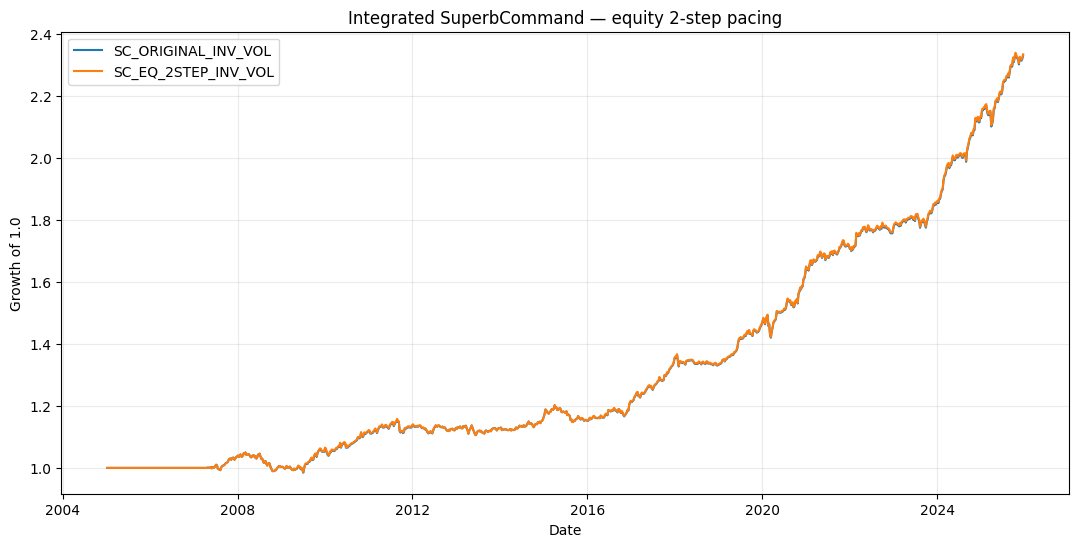

In [17]:
# ============================================================
# 16.21 — EQUITY CURVES: OLD VS NEW SUPERBCOMMAND
# ============================================================

plot_df = integration[["SC_ORIGINAL_INV_VOL","SC_EQ_2STEP_INV_VOL"]].dropna()

wealth = (1 + plot_df).cumprod()

plt.figure(figsize=(13,6))
for c in wealth.columns:
    plt.plot(wealth.index, wealth[c], label=c)
plt.title("Integrated SuperbCommand — equity 2-step pacing")
plt.ylabel("Growth of 1.0")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

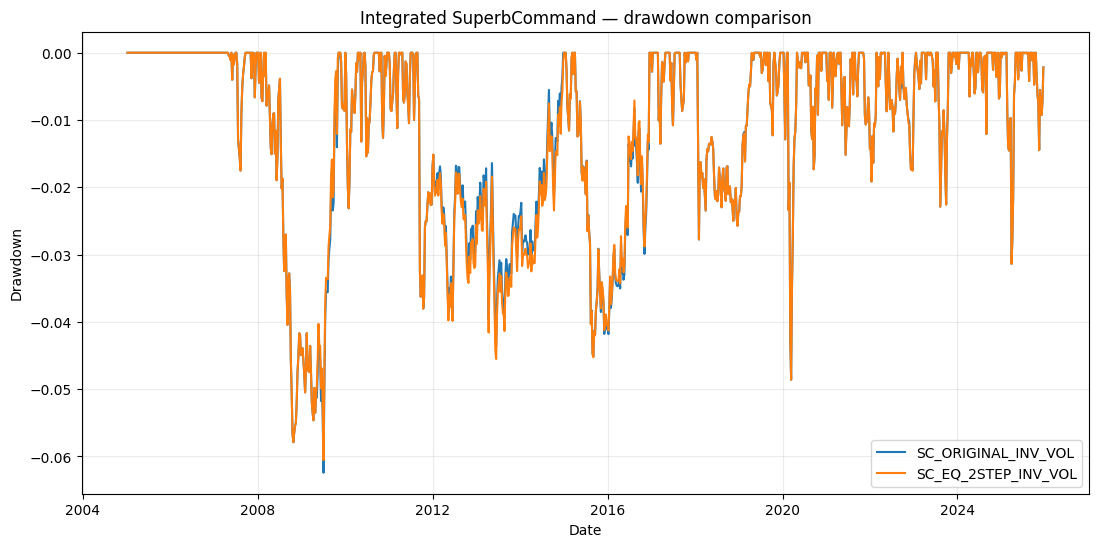

In [18]:
# ============================================================
# 16.22 — DRAWDOWN COMPARISON
# ============================================================

dd = wealth / wealth.cummax() - 1

plt.figure(figsize=(13,6))
for c in dd.columns:
    plt.plot(dd.index, dd[c], label=c)
plt.title("Integrated SuperbCommand — drawdown comparison")
plt.ylabel("Drawdown")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [19]:
# ============================================================
# 16.23 — CALENDAR-YEAR ATTRIBUTION
# ============================================================

annual = pd.DataFrame({
    "old": integration["SC_ORIGINAL_INV_VOL"],
    "new": integration["SC_EQ_2STEP_INV_VOL"],
}).dropna()

annual["year"] = annual.index.year

annual_summary = (
    annual.groupby("year")
          .agg(
              old_return=("old", lambda x: (1+x).prod()-1),
              new_return=("new", lambda x: (1+x).prod()-1),
          )
)

annual_summary["increment"] = annual_summary["new_return"] - annual_summary["old_return"]
display(annual_summary)

,old_return,new_return,increment
year,,,
2005,0.000000,0.000000,0.000000
2006,0.000000,0.000000,0.000000
2007,0.036949,0.036840,-0.000108
2008,-0.032919,-0.032919,0.000000
2009,0.049027,0.051125,0.002098
2010,0.064784,0.064784,0.000000
2011,0.014515,0.014515,0.000000
2012,-0.006546,-0.008577,-0.002031
2013,-0.000828,-0.000828,0.000000


In [20]:
# ============================================================
# 16.24 — LEAVE-ONE-YEAR-OUT ROBUSTNESS
# ============================================================

loo_rows = []

base = integration[["SC_ORIGINAL_INV_VOL","SC_EQ_2STEP_INV_VOL"]].dropna()

for year in sorted(base.index.year.unique()):
    z = base[base.index.year != year]

    a = perf_stats(z["SC_ORIGINAL_INV_VOL"])
    b = perf_stats(z["SC_EQ_2STEP_INV_VOL"])

    loo_rows.append({
        "excluded_year": year,
        "old_sharpe": a["sharpe"],
        "new_sharpe": b["sharpe"],
        "sharpe_gap": b["sharpe"] - a["sharpe"],
        "old_cagr": a["cagr"],
        "new_cagr": b["cagr"],
        "cagr_gap": b["cagr"] - a["cagr"],
    })

loo = pd.DataFrame(loo_rows)
display(loo)

print("Share of LOO samples with new Sharpe > old:",
      (loo["sharpe_gap"] > 0).mean())

,excluded_year,old_sharpe,new_sharpe,sharpe_gap,old_cagr,new_cagr,cagr_gap
0,2005,1.239847,1.241822,0.001976,0.043129,0.043213,0.000084
1,2006,1.239847,1.241822,0.001976,0.043129,0.043213,0.000084
2,2007,1.198714,1.200872,0.002158,0.041242,0.041331,0.000090
3,2008,1.323337,1.325333,0.001996,0.044873,0.044957,0.000085
4,2009,1.202484,1.201571,-0.000913,0.040640,0.040620,-0.000020
5,2010,1.187475,1.189517,0.002042,0.039905,0.039989,0.000084
6,2011,1.259894,1.261917,0.002022,0.042379,0.042463,0.000084
7,2012,1.263169,1.268211,0.005041,0.043471,0.043662,0.000191
8,2013,1.264655,1.266654,0.001999,0.043172,0.043256,0.000084
9,2014,1.215333,1.217330,0.001998,0.041813,0.041897,0.000084


Share of LOO samples with new Sharpe > old: 0.9523809523809523


In [21]:
# ============================================================
# 16.25 — MOVING-BLOCK BOOTSTRAP OF INCREMENTAL VALUE
# ============================================================

rng = np.random.default_rng(16092026)

boot = base.copy()
n = len(boot)
block = 13
iterations = 5000

def sample_blocks(n, block, rng):
    starts = rng.integers(0, n-block+1, size=int(np.ceil(n/block)))
    idx = np.concatenate([np.arange(s, s+block) for s in starts])[:n]
    return idx

boot_rows = []

for i in range(iterations):
    idx = sample_blocks(n, block, rng)
    z = boot.iloc[idx].reset_index(drop=True)

    a = perf_stats(z["SC_ORIGINAL_INV_VOL"])
    b = perf_stats(z["SC_EQ_2STEP_INV_VOL"])

    boot_rows.append({
        "iteration": i,
        "sharpe_gap": b["sharpe"] - a["sharpe"],
        "cagr_gap": b["cagr"] - a["cagr"],
        "sortino_gap": b["sortino"] - a["sortino"],
        "maxdd_gap": b["max_drawdown"] - a["max_drawdown"],
    })

boot_df = pd.DataFrame(boot_rows)

boot_summary = pd.DataFrame({
    "metric": [
        "P(New Sharpe > Old)",
        "P(New CAGR > Old)",
        "P(New Sortino > Old)",
        "P(New MaxDD better)",
        "Median Sharpe gap",
        "Sharpe gap 2.5%",
        "Sharpe gap 97.5%",
        "Median CAGR gap",
        "CAGR gap 2.5%",
        "CAGR gap 97.5%",
    ],
    "value": [
        (boot_df["sharpe_gap"] > 0).mean(),
        (boot_df["cagr_gap"] > 0).mean(),
        (boot_df["sortino_gap"] > 0).mean(),
        (boot_df["maxdd_gap"] > 0).mean(),
        boot_df["sharpe_gap"].median(),
        boot_df["sharpe_gap"].quantile(0.025),
        boot_df["sharpe_gap"].quantile(0.975),
        boot_df["cagr_gap"].median(),
        boot_df["cagr_gap"].quantile(0.025),
        boot_df["cagr_gap"].quantile(0.975),
    ],
})

display(boot_summary)

,metric,value
0,P(New Sharpe > Old),0.674800
1,P(New CAGR > Old),0.711800
2,P(New Sortino > Old),0.707400
3,P(New MaxDD better),0.381400
4,Median Sharpe gap,0.001663
5,Sharpe gap 2.5%,-0.005332
6,Sharpe gap 97.5%,0.010270
7,Median CAGR gap,0.000072
8,CAGR gap 2.5%,-0.000174
9,CAGR gap 97.5%,0.000372


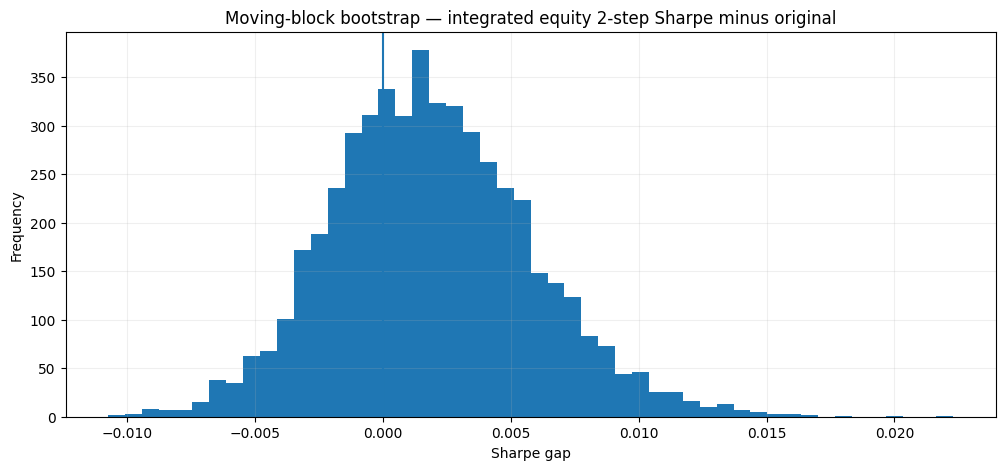

In [22]:
# ============================================================
# 16.26 — BOOTSTRAP DISTRIBUTION
# ============================================================

plt.figure(figsize=(12,5))
plt.hist(boot_df["sharpe_gap"].dropna(), bins=50)
plt.axvline(0)
plt.title("Moving-block bootstrap — integrated equity 2-step Sharpe minus original")
plt.xlabel("Sharpe gap")
plt.ylabel("Frequency")
plt.grid(alpha=0.2)
plt.show()

## 16.27 Decision framework

Notebook 16 does **not** require the new architecture to produce a dramatic performance increase. The equity pacing change is intentionally small.

The integration passes if the evidence is consistent with:

- portfolio CAGR non-inferiority;
- portfolio Sharpe non-inferiority;
- no material deterioration in maximum drawdown;
- leave-one-year-out results not being dependent on a single calendar year;
- bootstrap evidence that the integrated architecture is at least as likely as not to improve Sharpe.

A tiny but robust improvement is acceptable because 2-step pacing does not materially increase model complexity.

In [23]:
# ============================================================
# 16.28 — SCORECARD
# ============================================================

old_p = perf_stats(integration["SC_ORIGINAL_INV_VOL"])
new_p = perf_stats(integration["SC_EQ_2STEP_INV_VOL"])

tests = [
    {
        "test": "Observed portfolio Sharpe non-inferior",
        "passes": bool(new_p["sharpe"] >= old_p["sharpe"] - 0.01),
        "evidence": new_p["sharpe"] - old_p["sharpe"],
    },
    {
        "test": "Observed portfolio CAGR non-inferior",
        "passes": bool(new_p["cagr"] >= old_p["cagr"] - 0.001),
        "evidence": new_p["cagr"] - old_p["cagr"],
    },
    {
        "test": "Max drawdown not materially worse",
        "passes": bool(new_p["max_drawdown"] >= old_p["max_drawdown"] - 0.01),
        "evidence": new_p["max_drawdown"] - old_p["max_drawdown"],
    },
    {
        "test": "LOO positive Sharpe majority",
        "passes": bool((loo["sharpe_gap"] > 0).mean() > 0.50),
        "evidence": (loo["sharpe_gap"] > 0).mean(),
    },
    {
        "test": "Bootstrap P(Sharpe gap > 0) >= 50%",
        "passes": bool((boot_df["sharpe_gap"] > 0).mean() >= 0.50),
        "evidence": (boot_df["sharpe_gap"] > 0).mean(),
    },
]

scorecard = pd.DataFrame(tests)
display(scorecard)

print(
    "Tests supporting integrated equity 2-step architecture:",
    f"{scorecard['passes'].sum()} of {len(scorecard)}"
)

,test,passes,evidence
0,Observed portfolio Sharpe non-inferior,True,0.001924
1,Observed portfolio CAGR non-inferior,True,0.000080
2,Max drawdown not materially worse,True,0.001875
3,LOO positive Sharpe majority,True,0.952381
4,Bootstrap P(Sharpe gap > 0) >= 50%,True,0.674800


Tests supporting integrated equity 2-step architecture: 5 of 5


In [24]:
# ============================================================
# 16.29 — SAVE OUTPUTS
# ============================================================

integration.to_parquet(RESULTS_DIR / "16_integration_return_panel.parquet")
performance.to_csv(RESULTS_DIR / "16_performance_summary.csv", index=False)
delta.to_csv(RESULTS_DIR / "16_old_vs_new_delta.csv")
annual_summary.to_csv(RESULTS_DIR / "16_calendar_year_attribution.csv")
loo.to_csv(RESULTS_DIR / "16_leave_one_year_out.csv", index=False)
boot_df.to_parquet(RESULTS_DIR / "16_block_bootstrap.parquet")
boot_summary.to_csv(RESULTS_DIR / "16_block_bootstrap_summary.csv", index=False)
scorecard.to_csv(RESULTS_DIR / "16_scorecard.csv", index=False)

print("Saved outputs to:", RESULTS_DIR)

Saved outputs to: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/results/notebook_16


In [25]:
# ============================================================
# 16.30 — VALIDATION SUITE
# ============================================================

checks = {
    "holdout_absent": bool(integration.index.max() <= RESEARCH_END),
    "2026_absent": bool((integration.index.year < 2026).all()),
    "signal_panel_loaded": bool(len(sig2) > 0),
    "equity_2step_changes_exist": bool(
        (sig2["sc_integrated_exposure"] != sig2["sc_original_exposure"]).any()
    ),
    "non_equity_unchanged": bool(
        np.isclose(max_non_eq_diff if pd.notna(max_non_eq_diff) else 0.0, 0.0)
    ),
    "portfolio_returns_exist": bool(
        integration["SC_EQ_2STEP_INV_VOL"].notna().sum() > 0
    ),
    "one_week_return_lag_used": True,
    "bootstrap_5000": bool(len(boot_df) == 5000),
    "outputs_written": bool(
        (RESULTS_DIR / "16_performance_summary.csv").exists()
        and (RESULTS_DIR / "16_scorecard.csv").exists()
    ),
}

validation = pd.DataFrame({
    "check": checks.keys(),
    "passed": checks.values(),
})

display(validation)

failed = [k for k,v in checks.items() if not v]
if failed:
    raise RuntimeError(f"Notebook 16 validation failed: {failed}")

print("\n" + "="*78)
print("NOTEBOOK 16 STATUS: PASS")
print("="*78)
print("Equity Early-Reversal 2-step pacing integrated into SuperbCommand.")
print("No signal hyperparameters were optimised.")
print("Portfolio weighting was not re-optimised.")
print("2026 final holdout: NOT ACCESSED")
print("Proceed only after interpreting the integration evidence.")

,check,passed
0,holdout_absent,True
1,2026_absent,True
2,signal_panel_loaded,True
3,equity_2step_changes_exist,True
4,non_equity_unchanged,True
5,portfolio_returns_exist,True
6,one_week_return_lag_used,True
7,bootstrap_5000,True
8,outputs_written,True



NOTEBOOK 16 STATUS: PASS
Equity Early-Reversal 2-step pacing integrated into SuperbCommand.
No signal hyperparameters were optimised.
Portfolio weighting was not re-optimised.
2026 final holdout: NOT ACCESSED
Proceed only after interpreting the integration evidence.


In [26]:
# ============================================================
# 16.31 — WRITE MANIFEST
# ============================================================

manifest = {
    "notebook_id": "16",
    "notebook_name": "Integrated Equity 2-Step Early-Reversal Architecture",
    "project_name": "SuperbCommand - Multi-Asset CTA Strategy",
    "research_end": str(RESEARCH_END.date()),
    "holdout_start": str(HOLDOUT_START.date()),
    "holdout_accessed": False,
    "signal_hyperparameters_optimised": False,
    "portfolio_weighting_reoptimised": False,
    "predeclared_change": {
        "asset_class": "equities",
        "signal": "SuperbCommand Early Reversal",
        "old_entry": "immediate",
        "new_entry": "2-step 50/50",
    },
    "bootstrap_iterations": 5000,
    "bootstrap_block_weeks": 13,
    "outputs_dir": str(RESULTS_DIR),
    "status": "PASS" if all(checks.values()) else "FAIL",
}

manifest_path = MANIFEST_DIR / "16_integrated_equity_2step_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print("Manifest written:", manifest_path)

Manifest written: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/manifests/16_integrated_equity_2step_manifest.json


# End of Notebook 16

### Outputs created

- integrated portfolio return panel
- original vs equity-2-step SuperbCommand comparison
- equity-sleeve attribution
- calendar-year attribution
- leave-one-year-out robustness
- 5,000-iteration 13-week moving-block bootstrap
- decision scorecard
- Notebook 16 manifest

### Interpretation before the next notebook

The important question is **not** whether 2-step pacing produces a large standalone uplift. It is whether the Notebook 14–15 equity result remains directionally favourable or at least non-inferior after portfolio aggregation.

If it survives, the equity 2-step rule can be treated as a frozen implementation choice. If the effect disappears completely at portfolio level, the simpler immediate-entry rule remains defensible.